In [68]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

In [69]:
df=pd.read_csv('Data/titanic.csv')
df.dropna(subset=['Sex', 'Fare', 'Survived'], inplace=True)


In [70]:
x_fare = df['Fare'].values.reshape(-1,1)
df['Sex_num'] = df['Sex'].map({'female':0, 'male':1})
dummies = pd.get_dummies(df['Sex'], drop_first=True)  # erzeugt eine Spalte "male"
x_sex = dummies.values.reshape(-1,1)  # 2D Array für sklearn
y=df['Survived'].values

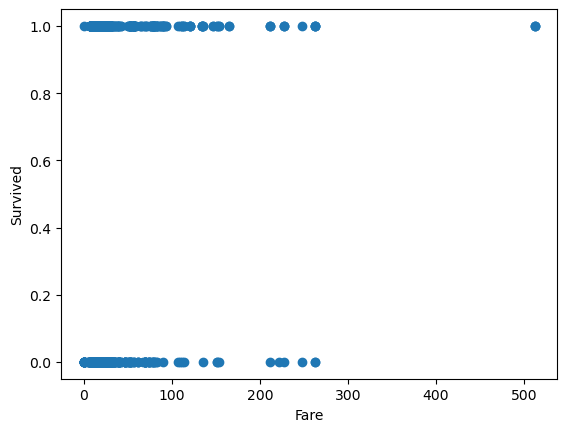

In [71]:
plt.plot(x_fare, y, 'o')
plt.xlabel('Fare')
plt.ylabel('Survived')
plt.show()

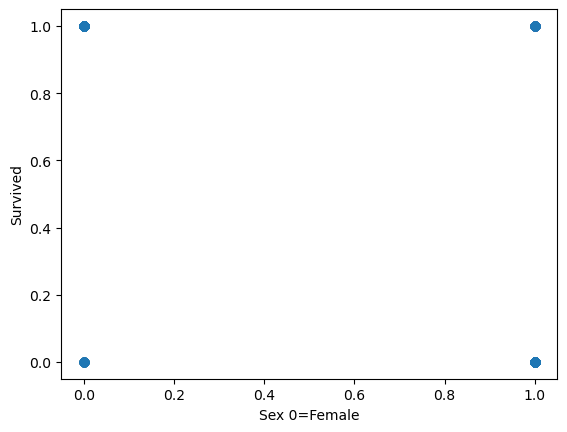

In [72]:
plt.plot(x_sex, y, 'o')
plt.xlabel('Sex 0=Female')
plt.ylabel('Survived')
plt.show()

In [73]:
logreg_fare = LogisticRegression(penalty = None)
logreg_fare.fit(x_fare, y)
y_pred_fare = logreg_fare.predict(x_fare)
intercept_fare = logreg_fare.intercept_[0]
coef_fare = logreg_fare.coef_[0][0]
print(f"pi=1/1(1+exp(-({intercept_fare:.4f} + {coef_fare:.4f} * Fare)))")

pi=1/1(1+exp(-(-0.9413 + 0.0152 * Fare)))


In [74]:
logreg_sex = LogisticRegression(penalty = None)
logreg_sex.fit(x_sex, y)
y_pred_sex = logreg_sex.predict(x_sex)
intercept_sex = logreg_sex.intercept_[0]
coef_sex = logreg_sex.coef_[0][0]
print(f"pi=1/1(1+exp(-({intercept_sex:.4f} + {coef_sex:.4f} * Sex)))")

pi=1/1(1+exp(-(1.0574 + -2.5143 * Sex)))


In [75]:
frauen = df[df['Sex']=='female']
frauen_total = len(frauen)
überlebt = frauen['Survived'].sum()

wk = (überlebt / frauen_total) * 100
print(f'Wahrscheinlichkeit: {wk:.2f}%')


Wahrscheinlichkeit: 74.20%


In [76]:
cm_fare = metrics.confusion_matrix(y, y_pred_fare)
tn_fare, fp_fare, fn_fare, tp_fare = cm_fare.ravel()
print(f'tn_fare: {tn_fare}')
print(f'fp_fare: {fp_fare}')
print(f'fn_fare: {fn_fare}')
print(f'tp_fare: {tp_fare}')

tn_fare: 511
fp_fare: 38
fn_fare: 260
tp_fare: 82


In [77]:
cm_sex = metrics.confusion_matrix(y, y_pred_sex)
tn_sex, fp_sex, fn_sex, tp_sex = cm_sex.ravel()
print(f'tn_sex: {tn_sex}')
print(f'tp_sex: {tp_sex}')
print(f'fn_sex: {fn_sex}')
print(f'tp_sex: {tp_sex}')

tn_sex: 468
tp_sex: 233
fn_sex: 109
tp_sex: 233


In [78]:
genauigkeit_fare = metrics.accuracy_score(y, y_pred_fare) *100
print(f'genauigkeit_fare: {genauigkeit_fare:.2f}%')

genauigkeit_fare: 66.55%


In [79]:
genauigkeit_sex = metrics.accuracy_score(y, y_pred_sex)*100
print(f'Genauigkeit_sex:{genauigkeit_sex:.2f}%')

Genauigkeit_sex:78.68%
